# 🧪 GMM Clustering Model Testing
### Parallel & Distributed Computing — Milestone 1
**Embeddings Evaluated:** BGE (`bge_embeddings.csv`) & TF-IDF (`tf-idf_vector.csv`)  
**Clustering Algorithm:** Gaussian Mixture Model (GMM)  
**Number of Clusters:** 13 (verified from `Patient dominant_clusters.csv`)

---

## 📦 Section 1: Import Libraries & Load Embeddings

In [31]:
# ─── Standard & Scientific Libraries ───────────────────────────────────────────
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    jaccard_score
)
from sklearn.preprocessing import LabelEncoder

# ─── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

# ─── Display Settings ───────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [32]:
# ─── Load BGE Embeddings ────────────────────────────────────────────────────────
bge_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Final Datasets\bge_embedding.csv"
)

# ─── Load TF-IDF Vectors ────────────────────────────────────────────────────────
tfidf_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Final Datasets\tfidf_vector.csv"
)

# ─── Load Ground Truth Dominant Clusters ────────────────────────────────────────
ground_truth_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Final Datasets\PATIENT_DOMINANT_CLUSTERS.csv"
)

print("=" * 60)
print("📄 BGE Embeddings")
print(f"   Shape : {bge_df.shape}")
print(bge_df.head(3))

print("\n" + "=" * 60)
print("📄 TF-IDF Vectors")
print(f"   Shape : {tfidf_df.shape}")
print(tfidf_df.head(3))

print("\n" + "=" * 60)
print("📄 Ground Truth Dominant Clusters")
print(f"   Shape : {ground_truth_df.shape}")
print(ground_truth_df.head(3))

📄 BGE Embeddings
   Shape : (10253, 385)
   HADM_ID       0       1      2       3       4       5      6      7  \
0   145834 -0.0328 -0.0223 0.0008 -0.0096  0.0612  0.0140 0.0499 0.0635   
1   185777 -0.0081 -0.0220 0.0094  0.0367  0.0305 -0.0595 0.0430 0.0987   
2   107064 -0.0352 -0.0128 0.0501  0.0254 -0.0167 -0.0640 0.0460 0.0660   

        8       9      10      11      12      13      14      15     16  \
0 -0.0028  0.0158 -0.0087 -0.0243 -0.0078  0.0326 -0.0429 -0.0074 0.0280   
1 -0.0459 -0.0392 -0.0022 -0.0062 -0.0311 -0.0050 -0.0265 -0.0138 0.0060   
2 -0.0588 -0.0497  0.0016 -0.0352 -0.0035 -0.0493 -0.0095  0.0392 0.0654   

       17      18      19      20      21      22      23     24     25  \
0 -0.0139 -0.0454  0.0852  0.0435  0.0125 -0.0147 -0.0266 0.0523 0.0010   
1 -0.0334 -0.0573 -0.0018 -0.0033  0.0157  0.0170 -0.0233 0.0015 0.0378   
2 -0.0106 -0.0854  0.0032  0.0561 -0.0124  0.0065  0.0028 0.0257 0.0003   

      26     27      28      29      30     31      

In [33]:
# ─── Verify Number of Unique Clusters ───────────────────────────────────────────
cluster_col = [col for col in ground_truth_df.columns if 'cluster_id' in col.lower()][0]
hadm_col    = [col for col in ground_truth_df.columns if 'hadm'    in col.lower()][0]

n_clusters = ground_truth_df[cluster_col].nunique()
print(f"✅ Number of unique dominant clusters found: {n_clusters}")
print(f"   Cluster column  : '{cluster_col}'")
print(f"   HADM-ID  column : '{hadm_col}'")
print("\nCluster value counts:")
print(ground_truth_df[cluster_col].value_counts().sort_index())

N_CLUSTERS = 13   # confirmed

✅ Number of unique dominant clusters found: 13
   Cluster column  : 'DOMINANT_CPT_CLUSTER_ID'
   HADM-ID  column : 'HADM_ID'

Cluster value counts:
DOMINANT_CPT_CLUSTER_ID
0     9356
1      240
2      794
3     2992
4       80
5       64
6      186
7       11
8        3
9       57
10       9
11       7
12       3
Name: count, dtype: int64


In [34]:
# ─── Separate hadm_id from Feature Columns ──────────────────────────────────────

# --- BGE ---
bge_hadm_col = [c for c in bge_df.columns if 'hadm' in c.lower()]
if bge_hadm_col:
    bge_hadm_ids   = bge_df[bge_hadm_col[0]].values
    bge_features   = bge_df.drop(columns=bge_hadm_col).values
    print(f"BGE  → hadm_id column : '{bge_hadm_col[0]}'  | Feature shape: {bge_features.shape}")
else:
    bge_hadm_ids   = np.arange(len(bge_df))
    bge_features   = bge_df.values
    print(f"BGE  → No hadm_id column found. Using row index. Feature shape: {bge_features.shape}")

# --- TF-IDF ---
tfidf_hadm_col = [c for c in tfidf_df.columns if 'hadm' in c.lower()]
if tfidf_hadm_col:
    tfidf_hadm_ids  = tfidf_df[tfidf_hadm_col[0]].values
    tfidf_features  = tfidf_df.drop(columns=tfidf_hadm_col).values
    print(f"TF-IDF → hadm_id column : '{tfidf_hadm_col[0]}'  | Feature shape: {tfidf_features.shape}")
else:
    tfidf_hadm_ids  = np.arange(len(tfidf_df))
    tfidf_features  = tfidf_df.values
    print(f"TF-IDF → No hadm_id column found. Using row index. Feature shape: {tfidf_features.shape}")

# --- Ground Truth labels aligned by hadm_id ---
gt_lookup = dict(zip(ground_truth_df[hadm_col].values, ground_truth_df[cluster_col].values))

bge_gt_labels   = np.array([gt_lookup.get(h, -1) for h in bge_hadm_ids])
tfidf_gt_labels = np.array([gt_lookup.get(h, -1) for h in tfidf_hadm_ids])

print(f"\n✅ Ground truth labels aligned.")
print(f"   BGE   unmatched rows : {(bge_gt_labels   == -1).sum()}")
print(f"   TF-IDF unmatched rows: {(tfidf_gt_labels == -1).sum()}")

BGE  → hadm_id column : 'HADM_ID'  | Feature shape: (10253, 384)
TF-IDF → hadm_id column : 'HADM_ID'  | Feature shape: (10253, 2923)

✅ Ground truth labels aligned.
   BGE   unmatched rows : 2419
   TF-IDF unmatched rows: 2419


---
## 🔀 Section 2: Data Preprocessing & Train-Test Split

### 📌 Why a 5% Test Split?

> **GMM is an unsupervised learning method** — the model does not require labelled data for training. The cluster structure is learned entirely from the distribution of the input features.  
>
> A **95% / 5% split** is justified for the following reasons:
> - **Maximise cluster fidelity:** GMM needs sufficient observations to accurately estimate the mean, covariance, and mixing weights of all 13 Gaussian components. Keeping 95% of the data for fitting ensures robust parameter estimates.
> - **Held-out generalisation check:** The 5% test set lets us check whether the learnt cluster centroids generalise to unseen patient records without wasting training data.
> - **Dataset size consideration:** Medical NLP datasets tend to be expensive to produce; preserving as many samples as possible for learning is best practice.
> - **Stratification:** We stratify on ground-truth cluster labels so all 13 cluster types are represented in both splits.

In [35]:
# ─── Encode ground-truth labels to integers for stratification ──────────────────
le = LabelEncoder()
le.fit(np.concatenate([bge_gt_labels, tfidf_gt_labels]))

bge_gt_enc   = le.transform(bge_gt_labels)
tfidf_gt_enc = le.transform(tfidf_gt_labels)

# ─── BGE Split ──────────────────────────────────────────────────────────────────
(bge_X_train, bge_X_test,
 bge_y_train, bge_y_test,
 bge_id_train, bge_id_test) = train_test_split(
    bge_features,
    bge_gt_enc,
    bge_hadm_ids,
    test_size=0.05,
    random_state=42,
    stratify=bge_gt_enc
)

# ─── TF-IDF Split ───────────────────────────────────────────────────────────────
(tfidf_X_train, tfidf_X_test,
 tfidf_y_train, tfidf_y_test,
 tfidf_id_train, tfidf_id_test) = train_test_split(
    tfidf_features,
    tfidf_gt_enc,
    tfidf_hadm_ids,
    test_size=0.05,
    random_state=42,
    stratify=tfidf_gt_enc
)

print("✅ Train-test splits created with 95% / 5% ratio (stratified).\n")
print(f"{'Split':<12} {'BGE Train':>12} {'BGE Test':>10} {'TF-IDF Train':>14} {'TF-IDF Test':>12}")
print("-" * 62)
print(f"{'Samples':<12} {bge_X_train.shape[0]:>12} {bge_X_test.shape[0]:>10} "
      f"{tfidf_X_train.shape[0]:>14} {tfidf_X_test.shape[0]:>12}")
print(f"{'Features':<12} {bge_X_train.shape[1]:>12} {bge_X_test.shape[1]:>10} "
      f"{tfidf_X_train.shape[1]:>14} {tfidf_X_test.shape[1]:>12}")

✅ Train-test splits created with 95% / 5% ratio (stratified).

Split           BGE Train   BGE Test   TF-IDF Train  TF-IDF Test
--------------------------------------------------------------
Samples              9740        513           9740          513
Features              384        384           2923         2923


---
## 🔵 Section 3: GMM Clustering on BGE Embeddings

In [36]:
# ─── Fit GMM on BGE Training Data ───────────────────────────────────────────────
print("⏳ Fitting GMM on BGE embeddings …")

bge_gmm = GaussianMixture(
    n_components  = N_CLUSTERS,
    covariance_type = 'full',
    max_iter      = 200,
    n_init        = 5,
    random_state  = 42
)

bge_start = time.time()
bge_gmm.fit(bge_X_train)
bge_end   = time.time()
bge_runtime = bge_end - bge_start

# ─── Predict ────────────────────────────────────────────────────────────────────
bge_train_preds = bge_gmm.predict(bge_X_train)
bge_test_preds  = bge_gmm.predict(bge_X_test)

print(f"\n✅ BGE GMM fitted in {bge_runtime:.4f} seconds.")
print(f"   Converged        : {bge_gmm.converged_}")
print(f"   Iterations       : {bge_gmm.n_iter_}")
print(f"   Train predictions: {len(bge_train_preds)}  unique clusters used: {np.unique(bge_train_preds)}")
print(f"   Test  predictions: {len(bge_test_preds)}   unique clusters used: {np.unique(bge_test_preds)}")

⏳ Fitting GMM on BGE embeddings …

✅ BGE GMM fitted in 115.6684 seconds.
   Converged        : True
   Iterations       : 7
   Train predictions: 9740  unique clusters used: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
   Test  predictions: 513   unique clusters used: [ 0  1  2  3  4  5  6  7  9 10 11 12]


In [37]:
# ─── BGE Cluster Groupings ───────────────────────────────────────────────────────
bge_cluster_counts = pd.Series(bge_train_preds).value_counts().sort_index()
print("📊 BGE — Documents per Predicted Cluster (Training Set):\n")
print(f"{'Cluster':>10} {'Count':>10}")
print("-" * 22)
for cluster_id, count in bge_cluster_counts.items():
    print(f"{cluster_id:>10} {count:>10}")

📊 BGE — Documents per Predicted Cluster (Training Set):

   Cluster      Count
----------------------
         0        698
         1       1454
         2        462
         3        965
         4        977
         5       1003
         6        349
         7        660
         8        206
         9        910
        10        555
        11        633
        12        868


---
## 🟠 Section 4: GMM Clustering on TF-IDF Embeddings

In [38]:
# ─── Fit GMM on TF-IDF Training Data ────────────────────────────────────────────
print("⏳ Fitting GMM on TF-IDF embeddings …")

tfidf_gmm = GaussianMixture(
    n_components    = N_CLUSTERS,
    covariance_type = 'full',
    max_iter        = 200,
    n_init          = 5,
    random_state    = 42
)

tfidf_start = time.time()
tfidf_gmm.fit(tfidf_X_train)
tfidf_end   = time.time()
tfidf_runtime = tfidf_end - tfidf_start

# ─── Predict ────────────────────────────────────────────────────────────────────
tfidf_train_preds = tfidf_gmm.predict(tfidf_X_train)
tfidf_test_preds  = tfidf_gmm.predict(tfidf_X_test)

print(f"\n✅ TF-IDF GMM fitted in {tfidf_runtime:.4f} seconds.")
print(f"   Converged        : {tfidf_gmm.converged_}")
print(f"   Iterations       : {tfidf_gmm.n_iter_}")
print(f"   Train predictions: {len(tfidf_train_preds)}  unique clusters used: {np.unique(tfidf_train_preds)}")
print(f"   Test  predictions: {len(tfidf_test_preds)}   unique clusters used: {np.unique(tfidf_test_preds)}")

⏳ Fitting GMM on TF-IDF embeddings …

✅ TF-IDF GMM fitted in 5701.1531 seconds.
   Converged        : True
   Iterations       : 15
   Train predictions: 9740  unique clusters used: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
   Test  predictions: 513   unique clusters used: [ 0  4  8 10]


In [39]:
# ─── TF-IDF Cluster Groupings ────────────────────────────────────────────────────
tfidf_cluster_counts = pd.Series(tfidf_train_preds).value_counts().sort_index()
print("📊 TF-IDF — Documents per Predicted Cluster (Training Set):\n")
print(f"{'Cluster':>10} {'Count':>10}")
print("-" * 22)
for cluster_id, count in tfidf_cluster_counts.items():
    print(f"{cluster_id:>10} {count:>10}")

📊 TF-IDF — Documents per Predicted Cluster (Training Set):

   Cluster      Count
----------------------
         0        957
         1        273
         2        791
         3         20
         4       2707
         5        109
         6         65
         7         59
         8       2483
         9        619
        10       1538
        11          2
        12        117


---
## 🎨 Section 5: Cluster Visualization

In [40]:
# ─── PCA Dimensionality Reduction ────────────────────────────────────────────────
pca_bge   = PCA(n_components=2, random_state=42)
pca_tfidf = PCA(n_components=2, random_state=42)

bge_2d_train   = pca_bge.fit_transform(bge_X_train)
bge_2d_test    = pca_bge.transform(bge_X_test)

tfidf_2d_train = pca_tfidf.fit_transform(tfidf_X_train)
tfidf_2d_test  = pca_tfidf.transform(tfidf_X_test)

print(f"✅ PCA complete.")
print(f"   BGE   explained variance ratio (2 PCs): {pca_bge.explained_variance_ratio_.sum():.4f}")
print(f"   TF-IDF explained variance ratio (2 PCs): {pca_tfidf.explained_variance_ratio_.sum():.4f}")

✅ PCA complete.
   BGE   explained variance ratio (2 PCs): 0.2316
   TF-IDF explained variance ratio (2 PCs): 0.7826


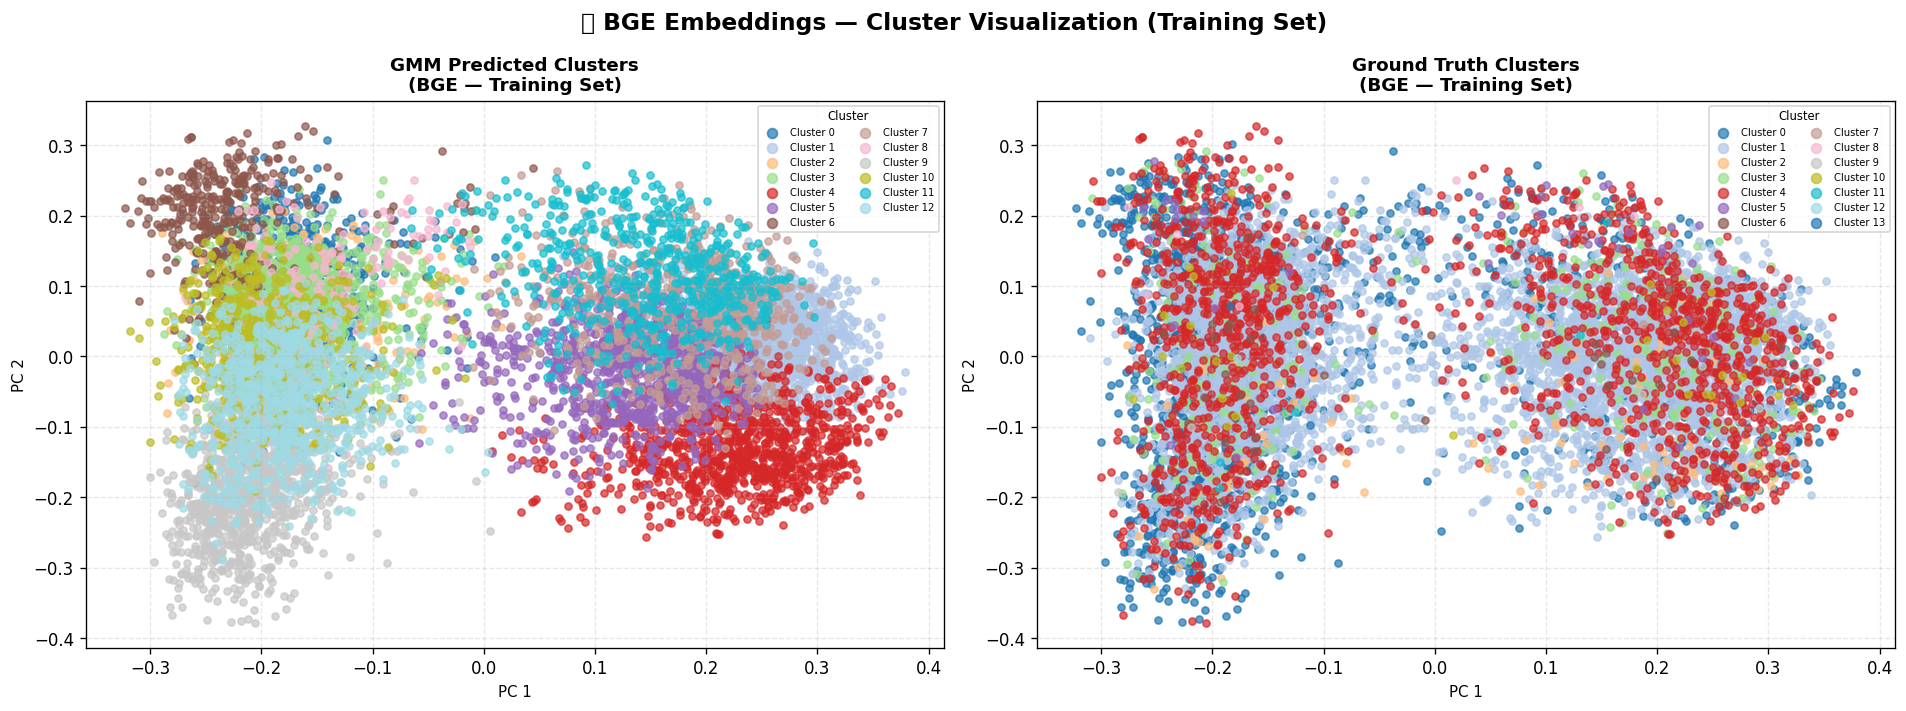

✅ BGE cluster visualization saved.


In [41]:
# ─── Colour Palette for 13 Clusters ─────────────────────────────────────────────
CMAP   = plt.cm.get_cmap('tab20', N_CLUSTERS)
COLORS = [CMAP(i) for i in range(N_CLUSTERS)]

def scatter_clusters(ax, X_2d, labels, title, subtitle=""):
    unique_labels = np.unique(labels)
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            s=18, alpha=0.7,
            color=COLORS[lbl % N_CLUSTERS],
            label=f'Cluster {lbl}'
        )
    ax.set_title(f"{title}\n{subtitle}", fontsize=11, fontweight='bold')
    ax.set_xlabel("PC 1", fontsize=9)
    ax.set_ylabel("PC 2", fontsize=9)
    ax.legend(
        loc='upper right', fontsize=6,
        markerscale=1.4, ncol=2,
        title="Cluster", title_fontsize=7
    )
    ax.grid(True, linestyle='--', alpha=0.3)

# ─── Figure 1: BGE — Predicted vs Ground Truth ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🔵 BGE Embeddings — Cluster Visualization (Training Set)", fontsize=14, fontweight='bold')

scatter_clusters(axes[0], bge_2d_train, bge_train_preds,
                 "GMM Predicted Clusters", "(BGE — Training Set)")
scatter_clusters(axes[1], bge_2d_train, bge_y_train,
                 "Ground Truth Clusters", "(BGE — Training Set)")

plt.tight_layout()
plt.savefig("bge_cluster_viz_complete_dataset.png", bbox_inches='tight')
plt.show()
print("✅ BGE cluster visualization saved.")

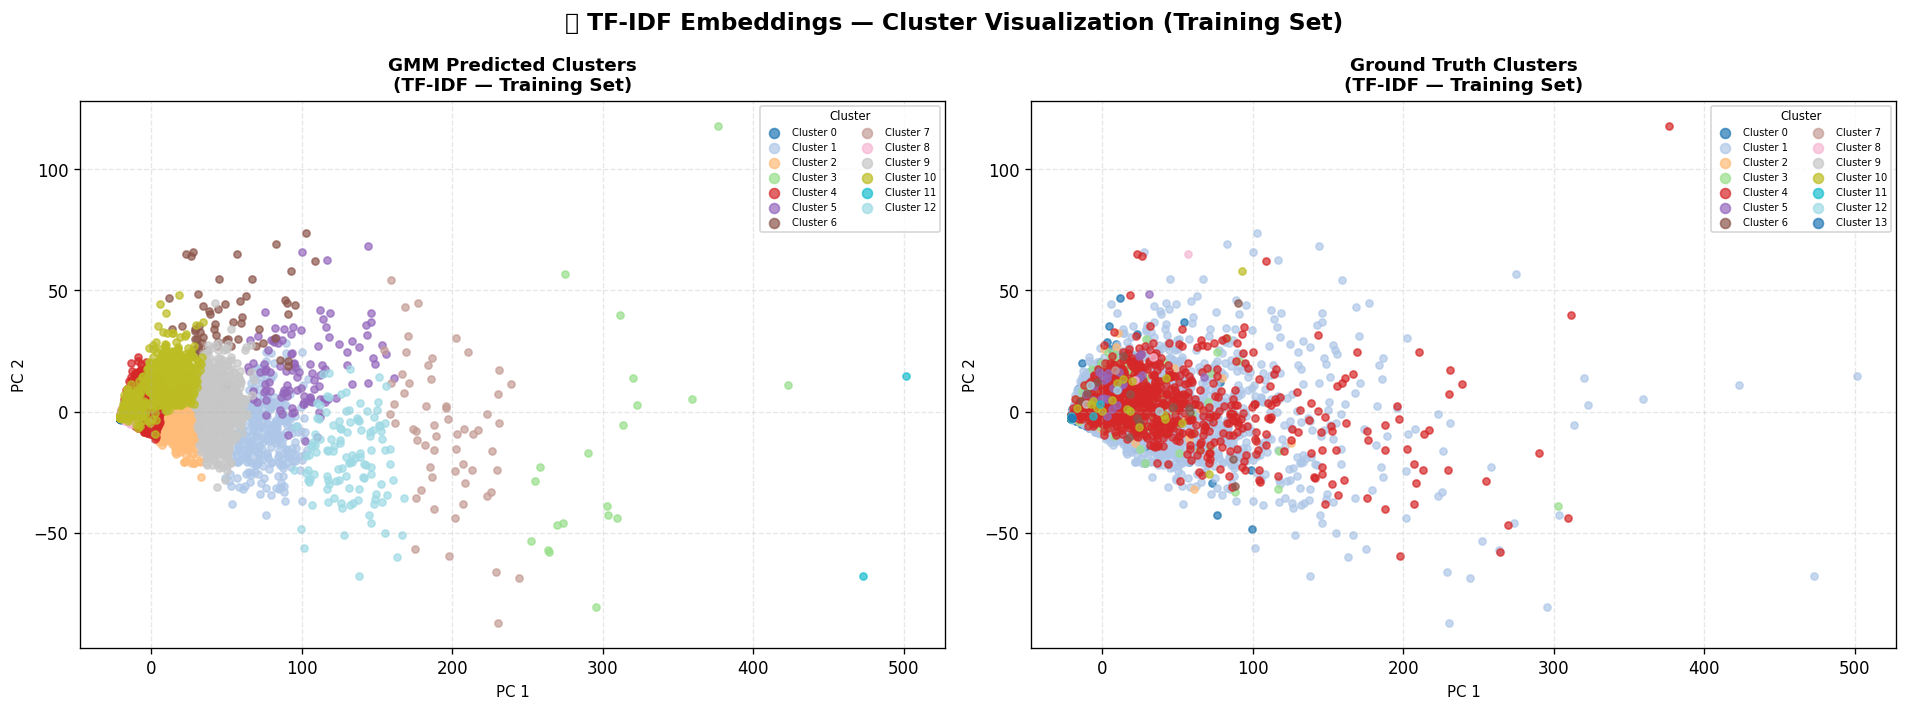

✅ TF-IDF cluster visualization saved.


In [42]:
# ─── Figure 2: TF-IDF — Predicted vs Ground Truth ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🟠 TF-IDF Embeddings — Cluster Visualization (Training Set)", fontsize=14, fontweight='bold')

scatter_clusters(axes[0], tfidf_2d_train, tfidf_train_preds,
                 "GMM Predicted Clusters", "(TF-IDF — Training Set)")
scatter_clusters(axes[1], tfidf_2d_train, tfidf_y_train,
                 "Ground Truth Clusters", "(TF-IDF — Training Set)")

plt.tight_layout()
plt.savefig("tfidf_cluster_viz_complete_dataset.png", bbox_inches='tight')
plt.show()
print("✅ TF-IDF cluster visualization saved.")

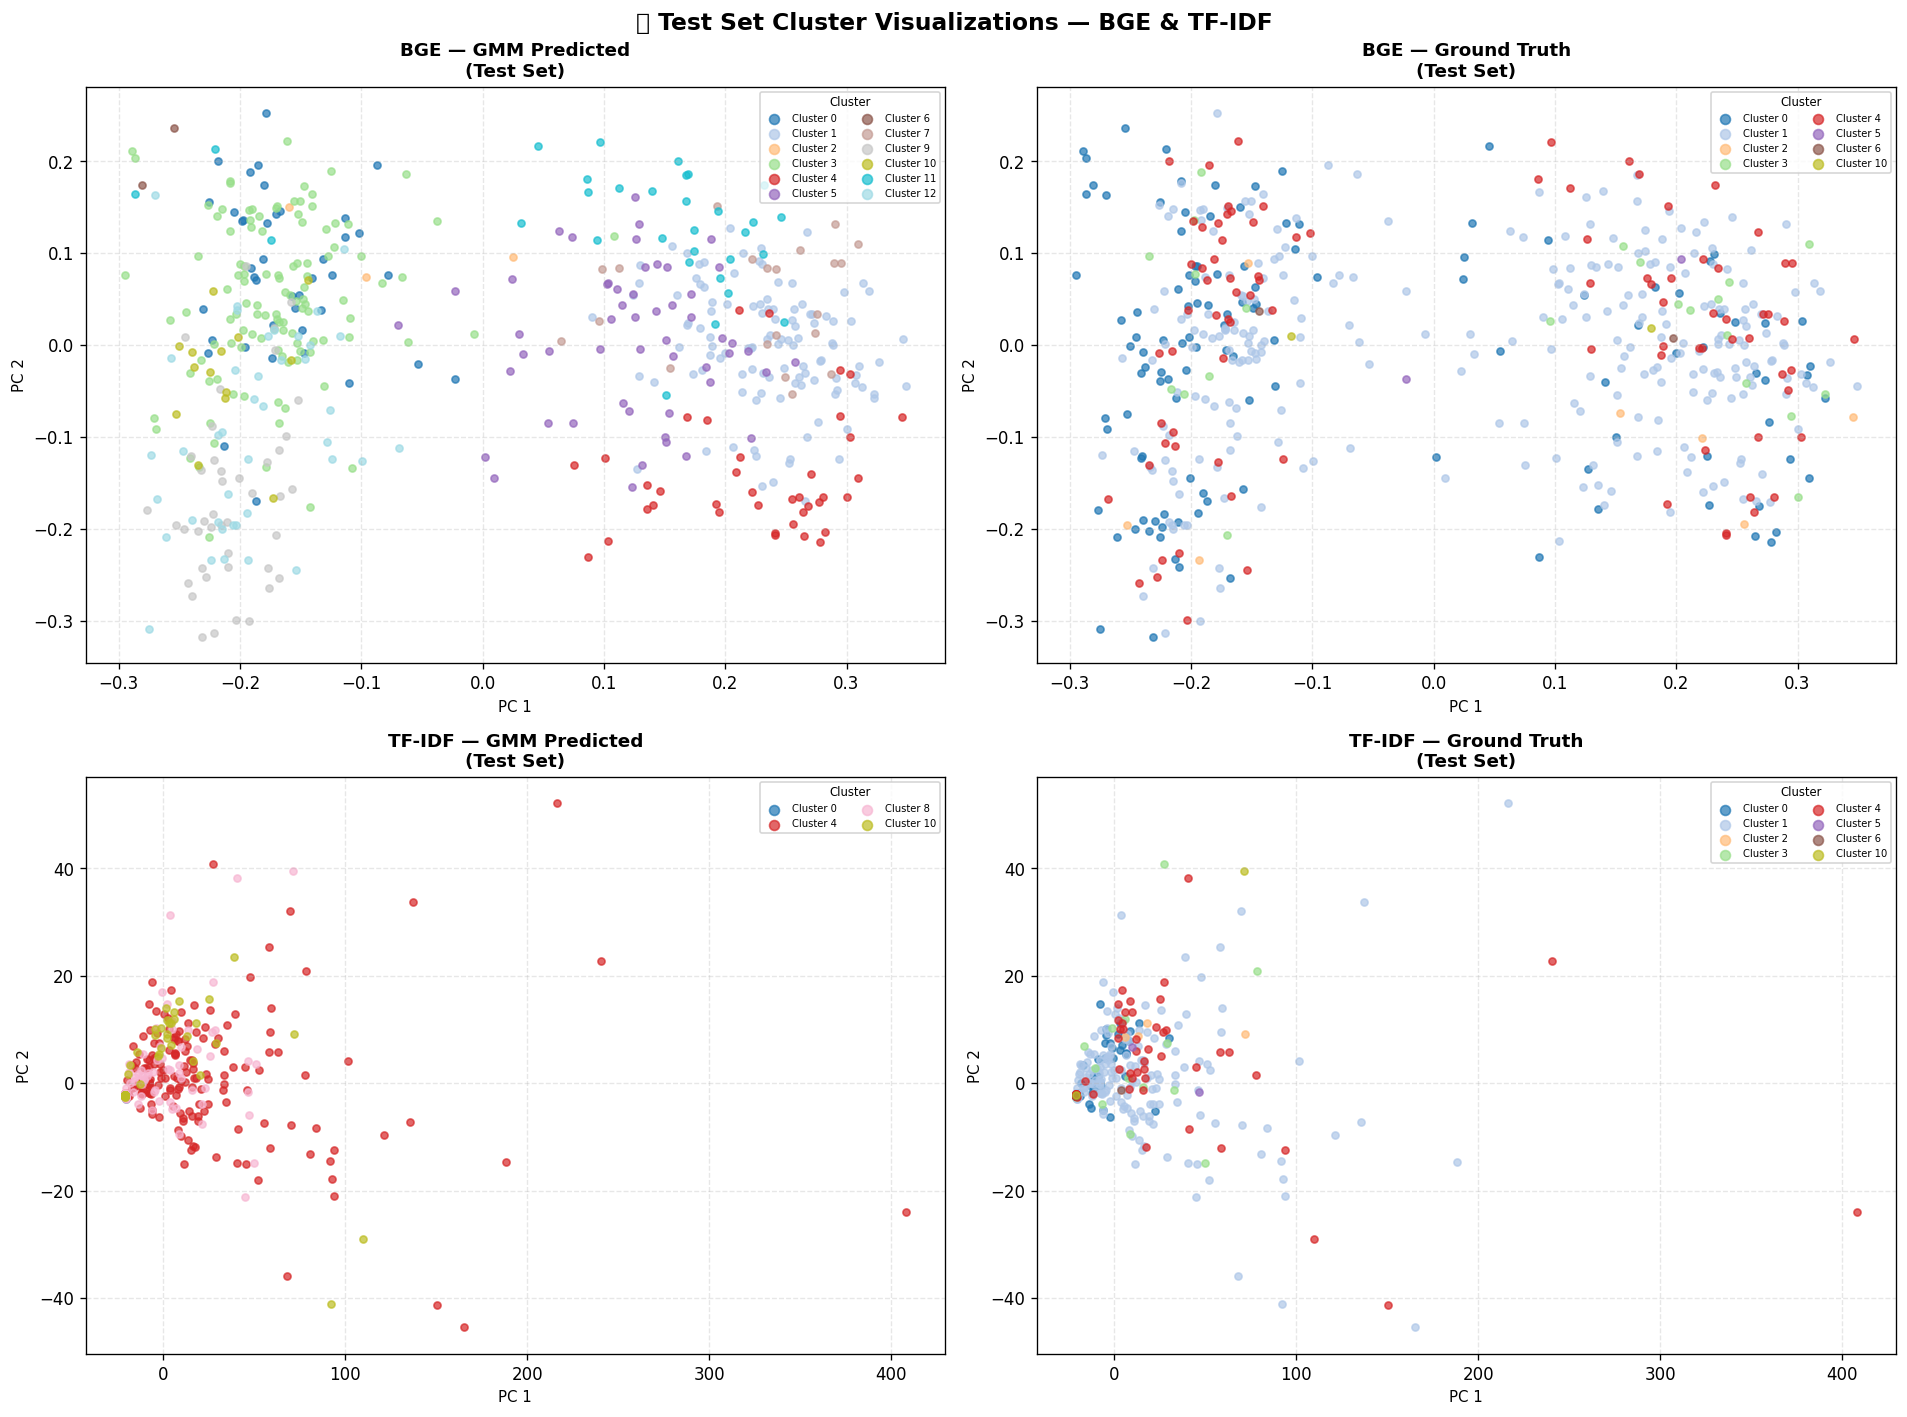

✅ Test set cluster visualization saved.


In [43]:
# ─── Figure 3: Test Set Scatter Plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("📊 Test Set Cluster Visualizations — BGE & TF-IDF", fontsize=14, fontweight='bold')

scatter_clusters(axes[0][0], bge_2d_test, bge_test_preds,
                 "BGE — GMM Predicted", "(Test Set)")
scatter_clusters(axes[0][1], bge_2d_test, bge_y_test,
                 "BGE — Ground Truth", "(Test Set)")
scatter_clusters(axes[1][0], tfidf_2d_test, tfidf_test_preds,
                 "TF-IDF — GMM Predicted", "(Test Set)")
scatter_clusters(axes[1][1], tfidf_2d_test, tfidf_y_test,
                 "TF-IDF — Ground Truth", "(Test Set)")

plt.tight_layout()
plt.savefig("test_cluster_viz_complete_dataset.png", bbox_inches='tight')
plt.show()
print("✅ Test set cluster visualization saved.")

---
## 📐 Section 6: Clustering Metrics — WSS & Silhouette Score

In [44]:
# ─── WSS Calculation using GMM component means ──────────────────────────────────
def compute_wss(X, labels, means):
    """
    Within-Cluster Sum of Squares:
    For each point, find its assigned cluster centroid (GMM mean),
    compute squared Euclidean distance, and sum over all points.
    """
    wss = 0.0
    for k in range(means.shape[0]):
        mask = labels == k
        if mask.sum() == 0:
            continue
        diff = X[mask] - means[k]
        wss += np.sum(diff ** 2)
    return wss

# ─── BGE Metrics ────────────────────────────────────────────────────────────────
bge_wss_train   = compute_wss(bge_X_train,   bge_train_preds, bge_gmm.means_)
bge_wss_test    = compute_wss(bge_X_test,    bge_test_preds,  bge_gmm.means_)
bge_sil_train   = silhouette_score(bge_X_train,   bge_train_preds, sample_size=2000, random_state=42)
bge_sil_test    = silhouette_score(bge_X_test,    bge_test_preds,  random_state=42)

# ─── TF-IDF Metrics ─────────────────────────────────────────────────────────────
tfidf_wss_train  = compute_wss(tfidf_X_train,  tfidf_train_preds, tfidf_gmm.means_)
tfidf_wss_test   = compute_wss(tfidf_X_test,   tfidf_test_preds,  tfidf_gmm.means_)
tfidf_sil_train  = silhouette_score(tfidf_X_train, tfidf_train_preds, sample_size=2000, random_state=42)
tfidf_sil_test   = silhouette_score(tfidf_X_test,  tfidf_test_preds,  random_state=42)

# ─── Display ────────────────────────────────────────────────────────────────────
metrics_wss_sil = pd.DataFrame({
    'Model'         : ['BGE (Train)', 'BGE (Test)', 'TF-IDF (Train)', 'TF-IDF (Test)'],
    'WSS'           : [bge_wss_train, bge_wss_test, tfidf_wss_train, tfidf_wss_test],
    'Silhouette Score': [bge_sil_train, bge_sil_test, tfidf_sil_train, tfidf_sil_test]
})

print("=" * 55)
print("    📊 WSS & Silhouette Score Summary")
print("=" * 55)
print(metrics_wss_sil.to_string(index=False))
print("=" * 55)

    📊 WSS & Silhouette Score Summary
         Model          WSS  Silhouette Score
   BGE (Train)    1598.6139            0.0545
    BGE (Test)      91.0320            0.0150
TF-IDF (Train) 5130796.2832           -0.0319
 TF-IDF (Test) 1081985.8111           -0.3226


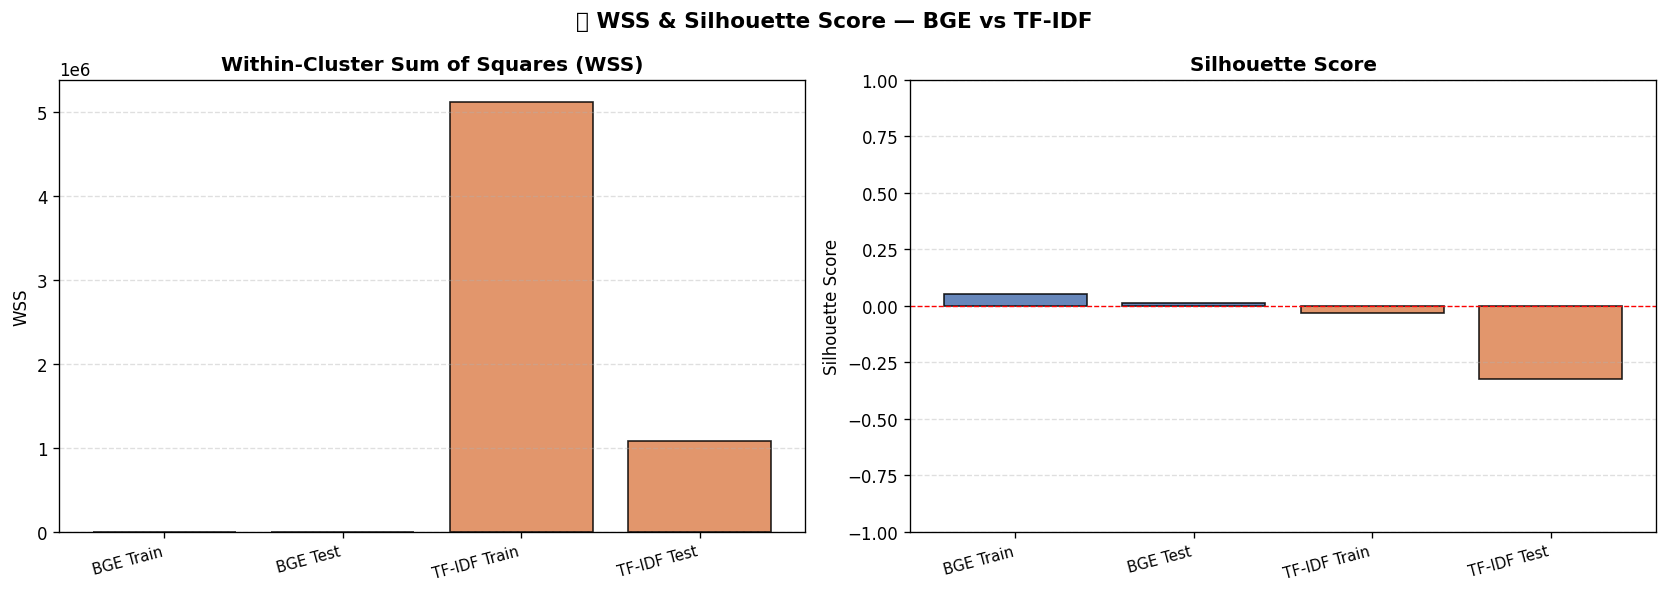

In [45]:
# ─── WSS Elbow-Style Bar Chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📐 WSS & Silhouette Score — BGE vs TF-IDF", fontsize=13, fontweight='bold')

labels_split = ['BGE Train', 'BGE Test', 'TF-IDF Train', 'TF-IDF Test']
wss_vals = [bge_wss_train, bge_wss_test, tfidf_wss_train, tfidf_wss_test]
sil_vals = [bge_sil_train, bge_sil_test, tfidf_sil_train, tfidf_sil_test]
bar_colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

axes[0].bar(labels_split, wss_vals, color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_title("Within-Cluster Sum of Squares (WSS)", fontweight='bold')
axes[0].set_ylabel("WSS")
axes[0].set_xticklabels(labels_split, rotation=15, ha='right', fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].bar(labels_split, sil_vals, color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_title("Silhouette Score", fontweight='bold')
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticklabels(labels_split, rotation=15, ha='right', fontsize=9)
axes[1].set_ylim([-1, 1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("wss_silhouette_chart_complete_dataset.png", bbox_inches='tight')
plt.show()

---
## 🏷️ Section 7: Cluster Label Assignment via Dominant Category

> Since GMM assigns arbitrary integer IDs to each cluster, we **remap** each predicted cluster to the **ground-truth label that appears most frequently** within it (majority vote). This lets us compute standard classification-style metrics in a fair, unsupervised manner.

In [46]:
# ─── Dominant Label Mapping Function ────────────────────────────────────────────
def build_dominant_mapping(y_true, y_pred, n_clusters):
    """
    For each predicted cluster, find the ground-truth label
    that appears most frequently (dominant category).
    Returns a dict: {predicted_cluster_id -> dominant_gt_label}
    """
    mapping = {}
    for k in range(n_clusters):
        mask = y_pred == k
        if mask.sum() == 0:
            mapping[k] = -1
            continue
        values, counts = np.unique(y_true[mask], return_counts=True)
        mapping[k] = values[np.argmax(counts)]
    return mapping

# ─── Build Mappings ─────────────────────────────────────────────────────────────
bge_map_train   = build_dominant_mapping(bge_y_train,   bge_train_preds,   N_CLUSTERS)
bge_map_test    = build_dominant_mapping(bge_y_test,    bge_test_preds,    N_CLUSTERS)

tfidf_map_train = build_dominant_mapping(tfidf_y_train, tfidf_train_preds, N_CLUSTERS)
tfidf_map_test  = build_dominant_mapping(tfidf_y_test,  tfidf_test_preds,  N_CLUSTERS)

# ─── Apply Mappings ─────────────────────────────────────────────────────────────
bge_remapped_train   = np.array([bge_map_train.get(p,  -1) for p in bge_train_preds])
bge_remapped_test    = np.array([bge_map_test.get(p,   -1) for p in bge_test_preds])

tfidf_remapped_train = np.array([tfidf_map_train.get(p, -1) for p in tfidf_train_preds])
tfidf_remapped_test  = np.array([tfidf_map_test.get(p,  -1) for p in tfidf_test_preds])

# ─── Print Mapping Tables ────────────────────────────────────────────────────────
def print_mapping_table(mapping, title):
    print(f"\n{'='*45}")
    print(f"  {title}")
    print(f"{'='*45}")
    print(f"  {'Predicted Cluster':>20} → {'Mapped GT Label':>15}")
    print(f"  {'-'*38}")
    for k, v in sorted(mapping.items()):
        gt_name = le.inverse_transform([v])[0] if v != -1 else 'N/A'
        print(f"  Cluster {k:>3}            → {gt_name:>15}")
    print(f"{'='*45}")

print_mapping_table(bge_map_train,   "BGE   — Dominant Mapping (Train)")
print_mapping_table(tfidf_map_train, "TF-IDF — Dominant Mapping (Train)")


  BGE   — Dominant Mapping (Train)
     Predicted Cluster → Mapped GT Label
  --------------------------------------
  Cluster   0            →               0
  Cluster   1            →               0
  Cluster   2            →              -1
  Cluster   3            →               0
  Cluster   4            →               0
  Cluster   5            →               0
  Cluster   6            →              -1
  Cluster   7            →               0
  Cluster   8            →              -1
  Cluster   9            →              -1
  Cluster  10            →               0
  Cluster  11            →               0
  Cluster  12            →               0

  TF-IDF — Dominant Mapping (Train)
     Predicted Cluster → Mapped GT Label
  --------------------------------------
  Cluster   0            →               0
  Cluster   1            →               0
  Cluster   2            →               0
  Cluster   3            →               0
  Cluster   4            →      

---
## 📊 Section 8: Purity, Rand Index & Jaccard Coefficient

In [47]:
# ─── Purity Calculation ──────────────────────────────────────────────────────────
def cluster_purity(y_true, y_remapped):
    correct = np.sum(y_true == y_remapped)
    return correct / len(y_true)

# ─── BGE ────────────────────────────────────────────────────────────────────────
bge_purity_train   = cluster_purity(bge_y_train,   bge_remapped_train)
bge_purity_test    = cluster_purity(bge_y_test,    bge_remapped_test)
bge_ari_train      = adjusted_rand_score(bge_y_train,   bge_train_preds)
bge_ari_test       = adjusted_rand_score(bge_y_test,    bge_test_preds)
bge_jaccard_train  = jaccard_score(bge_y_train,   bge_remapped_train,  average='weighted', zero_division=0)
bge_jaccard_test   = jaccard_score(bge_y_test,    bge_remapped_test,   average='weighted', zero_division=0)

# ─── TF-IDF ─────────────────────────────────────────────────────────────────────
tfidf_purity_train  = cluster_purity(tfidf_y_train,  tfidf_remapped_train)
tfidf_purity_test   = cluster_purity(tfidf_y_test,   tfidf_remapped_test)
tfidf_ari_train     = adjusted_rand_score(tfidf_y_train,  tfidf_train_preds)
tfidf_ari_test      = adjusted_rand_score(tfidf_y_test,   tfidf_test_preds)
tfidf_jaccard_train = jaccard_score(tfidf_y_train,  tfidf_remapped_train, average='weighted', zero_division=0)
tfidf_jaccard_test  = jaccard_score(tfidf_y_test,   tfidf_remapped_test,  average='weighted', zero_division=0)

# ─── Summary Table ───────────────────────────────────────────────────────────────
eval_metrics = pd.DataFrame({
    'Split'          : ['BGE Train',   'BGE Test',
                        'TF-IDF Train','TF-IDF Test'],
    'Purity'         : [bge_purity_train,   bge_purity_test,
                        tfidf_purity_train, tfidf_purity_test],
    'Adj Rand Index' : [bge_ari_train,      bge_ari_test,
                        tfidf_ari_train,    tfidf_ari_test],
    'Jaccard (Wtd)'  : [bge_jaccard_train,  bge_jaccard_test,
                        tfidf_jaccard_train,tfidf_jaccard_test],
})

print("=" * 65)
print("    📊 Cluster Evaluation Metrics")
print("=" * 65)
print(eval_metrics.to_string(index=False))
print("=" * 65)

    📊 Cluster Evaluation Metrics
       Split  Purity  Adj Rand Index  Jaccard (Wtd)
   BGE Train  0.5755          0.0411         0.3631
    BGE Test  0.5497          0.0309         0.3496
TF-IDF Train  0.5224          0.0065         0.2729
 TF-IDF Test  0.5263          0.0431         0.3086


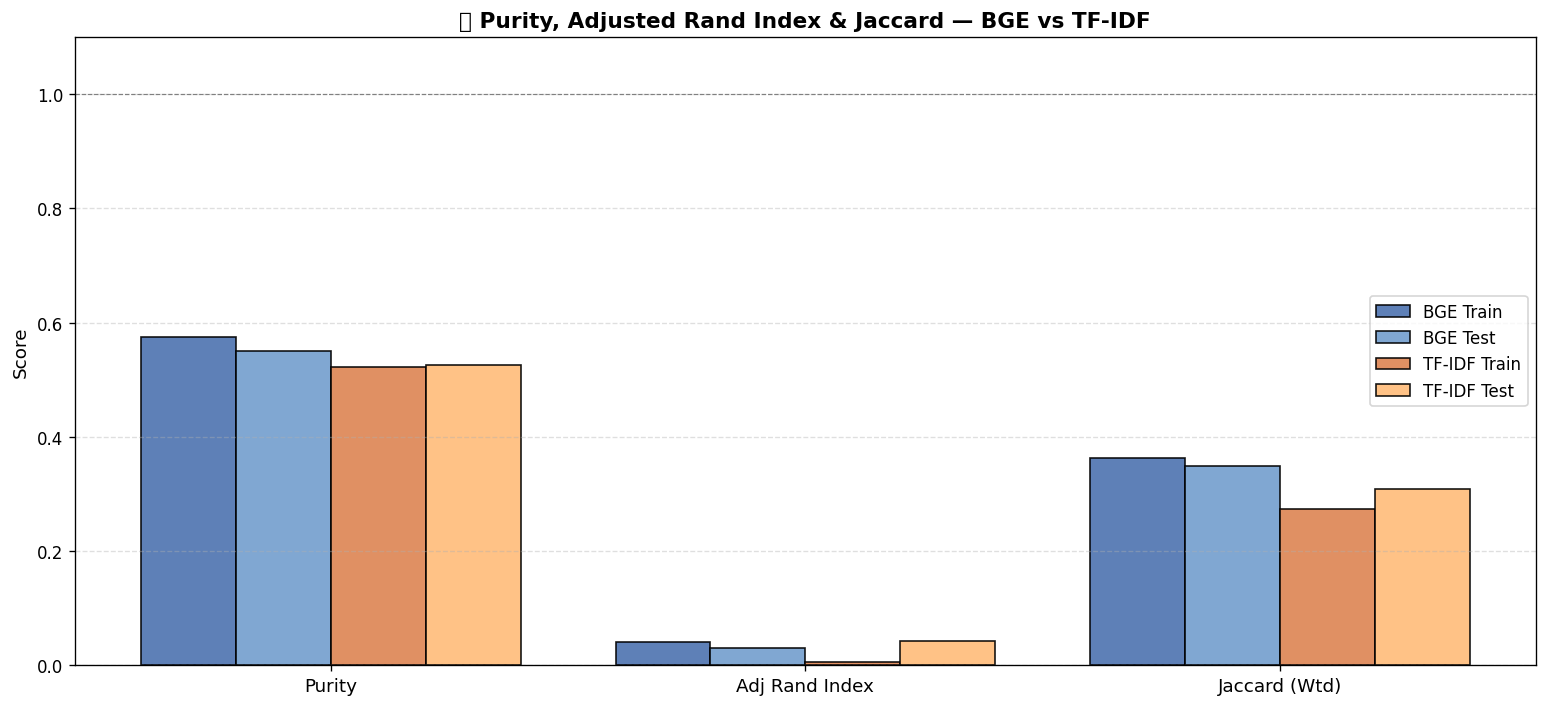

In [48]:
# ─── Visualization of Purity, ARI, Jaccard ───────────────────────────────────────
metrics_names = ['Purity', 'Adj Rand Index', 'Jaccard (Wtd)']
bge_vals_tr   = [bge_purity_train,   bge_ari_train,   bge_jaccard_train]
bge_vals_te   = [bge_purity_test,    bge_ari_test,    bge_jaccard_test]
tfidf_vals_tr = [tfidf_purity_train, tfidf_ari_train, tfidf_jaccard_train]
tfidf_vals_te = [tfidf_purity_test,  tfidf_ari_test,  tfidf_jaccard_test]

x = np.arange(len(metrics_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - 1.5*width, bge_vals_tr,   width, label='BGE Train',    color='#4C72B0', edgecolor='black', alpha=0.9)
ax.bar(x - 0.5*width, bge_vals_te,   width, label='BGE Test',     color='#729ECE', edgecolor='black', alpha=0.9)
ax.bar(x + 0.5*width, tfidf_vals_tr, width, label='TF-IDF Train', color='#DD8452', edgecolor='black', alpha=0.9)
ax.bar(x + 1.5*width, tfidf_vals_te, width, label='TF-IDF Test',  color='#FFBC79', edgecolor='black', alpha=0.9)

ax.set_title("📊 Purity, Adjusted Rand Index & Jaccard — BGE vs TF-IDF",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim([0, 1.1])
ax.axhline(1, color='grey', linestyle='--', linewidth=0.7)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("eval_metrics_chart_complete_dataset.png", bbox_inches='tight')
plt.show()

---
## 📋 Section 9: Results Tables with HADM IDs

In [49]:
# ─── Helper: Build Results DataFrame ────────────────────────────────────────────
def build_results_df(hadm_ids, y_true, y_pred, y_remapped, label_encoder, split_name):
    gt_names       = label_encoder.inverse_transform(y_true)
    remapped_names = np.where(y_remapped == -1, 'N/A',
                              label_encoder.inverse_transform(
                                  np.clip(y_remapped, 0, len(label_encoder.classes_)-1)
                              ))
    correct_flag = (y_true == y_remapped).astype(int)
    return pd.DataFrame({
        'Split'                  : split_name,
        'hadm_id'                : hadm_ids,
        'Ground Truth Cluster'   : gt_names,
        'Predicted Cluster (Raw)': y_pred,
        'Remapped Predicted'     : remapped_names,
        'Correct'                : correct_flag
    })

# ─── BGE Results ────────────────────────────────────────────────────────────────
bge_results_train = build_results_df(bge_id_train, bge_y_train,  bge_train_preds, bge_remapped_train,  le, 'Train')
bge_results_test  = build_results_df(bge_id_test,  bge_y_test,   bge_test_preds,  bge_remapped_test,   le, 'Test')
bge_results_all   = pd.concat([bge_results_train, bge_results_test], ignore_index=True)

# ─── TF-IDF Results ─────────────────────────────────────────────────────────────
tfidf_results_train = build_results_df(tfidf_id_train, tfidf_y_train, tfidf_train_preds, tfidf_remapped_train, le, 'Train')
tfidf_results_test  = build_results_df(tfidf_id_test,  tfidf_y_test,  tfidf_test_preds,  tfidf_remapped_test,  le, 'Test')
tfidf_results_all   = pd.concat([tfidf_results_train, tfidf_results_test], ignore_index=True)

print(f"✅ BGE   Results Table : {bge_results_all.shape[0]}  rows")
print(f"✅ TF-IDF Results Table: {tfidf_results_all.shape[0]} rows")

✅ BGE   Results Table : 10253  rows
✅ TF-IDF Results Table: 10253 rows


In [50]:
# ─── Display BGE Train Results (Sample) ──────────────────────────────────────────
print("🔵 BGE — Training Set Results (First 20 rows)")
print("=" * 85)
display(
    bge_results_train.head(20).style
    .applymap(lambda v: 'background-color: #d4edda; color: black' if v == 1 else
                        'background-color: #f8d7da; color: black', subset=['Correct'])
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#4C72B0'),
                                                     ('color', 'white'),
                                                     ('font-weight', 'bold')]}])
    .set_caption("BGE — Training Set Cluster Results")
)

🔵 BGE — Training Set Results (First 20 rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Train,174800,-1,3,0,0
1,Train,151197,-1,9,-1,1
2,Train,192507,0,1,0,1
3,Train,127776,0,5,0,1
4,Train,175586,3,1,0,0
5,Train,145503,2,10,0,0
6,Train,101148,0,1,0,1
7,Train,162569,-1,4,0,0
8,Train,166099,0,4,0,1
9,Train,166325,0,1,0,1


In [51]:
# ─── Display BGE Test Results ────────────────────────────────────────────────────
print("🔵 BGE — Test Set Results (All rows)")
print("=" * 85)
display(
    bge_results_test.style
    .applymap(lambda v: 'background-color: #d4edda; color: black' if v == 1 else
                        'background-color: #f8d7da; color: black', subset=['Correct'])
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#4C72B0'),
                                                     ('color', 'white'),
                                                     ('font-weight', 'bold')]}])
    .set_caption("BGE — Test Set Cluster Results")
)

🔵 BGE — Test Set Results (All rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Test,146882,0,1,0,1
1,Test,112299,-1,3,0,0
2,Test,117307,0,1,0,1
3,Test,105785,3,1,0,0
4,Test,165450,3,12,0,0
5,Test,162422,-1,1,0,0
6,Test,143652,1,4,0,0
7,Test,171389,-1,3,0,0
8,Test,174414,-1,5,0,0
9,Test,159171,3,0,3,1


In [52]:
# ─── Display TF-IDF Train Results (Sample) ──────────────────────────────────────
print("🟠 TF-IDF — Training Set Results (First 20 rows)")
print("=" * 85)
display(
    tfidf_results_train.head(20).style
    .applymap(lambda v: 'background-color: #d4edda; color: black' if v == 1 else
                        'background-color: #f8d7da; color: black', subset=['Correct'])
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#DD8452'),
                                                     ('color', 'white'),
                                                     ('font-weight', 'bold')]}])
    .set_caption("TF-IDF — Training Set Cluster Results")
)

🟠 TF-IDF — Training Set Results (First 20 rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Train,174800,-1,8,0,0
1,Train,151197,-1,10,0,0
2,Train,192507,0,4,0,1
3,Train,127776,0,2,0,1
4,Train,175586,3,3,0,0
5,Train,145503,2,10,0,0
6,Train,101148,0,4,0,1
7,Train,162569,-1,10,0,0
8,Train,166099,0,4,0,1
9,Train,166325,0,4,0,1


In [53]:
# ─── Display TF-IDF Test Results ────────────────────────────────────────────────
print("🟠 TF-IDF — Test Set Results (All rows)")
print("=" * 85)
display(
    tfidf_results_test.style
    .applymap(lambda v: 'background-color: #d4edda; color: black' if v == 1 else
                        'background-color: #f8d7da; color: black', subset=['Correct'])
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#DD8452'),
                                                     ('color', 'white'),
                                                     ('font-weight', 'bold')]}])
    .set_caption("TF-IDF — Test Set Cluster Results")
)

🟠 TF-IDF — Test Set Results (All rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Test,146882,0,4,0,1
1,Test,112299,-1,8,0,0
2,Test,117307,0,4,0,1
3,Test,105785,3,4,0,0
4,Test,165450,3,4,0,0
5,Test,162422,-1,4,0,0
6,Test,143652,1,10,-1,0
7,Test,171389,-1,8,0,0
8,Test,174414,-1,4,0,0
9,Test,159171,3,10,-1,0


In [54]:
# ─── Export Results to CSV ───────────────────────────────────────────────────────
bge_results_all.to_csv(
    r"c:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Milestone 1\bge_gmm_results.csv",
    index=False
)
tfidf_results_all.to_csv(
    r"c:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Milestone 1\tfidf_gmm_results.csv",
    index=False
)
print("✅ Results exported to CSV.")

✅ Results exported to CSV.


---
## 🏆 Section 10: Comparative Analysis & Best Model Summary

In [55]:
# ─── Consolidated Comparison Table ───────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Metric'              : ['WSS (Train)', 'WSS (Test)',
                             'Silhouette (Train)', 'Silhouette (Test)',
                             'Purity (Train)', 'Purity (Test)',
                             'Adj Rand Index (Train)', 'Adj Rand Index (Test)',
                             'Jaccard (Train)', 'Jaccard (Test)',
                             'Runtime (s)'],
    'BGE'                 : [bge_wss_train,    bge_wss_test,
                             bge_sil_train,    bge_sil_test,
                             bge_purity_train, bge_purity_test,
                             bge_ari_train,    bge_ari_test,
                             bge_jaccard_train,bge_jaccard_test,
                             bge_runtime],
    'TF-IDF'              : [tfidf_wss_train,    tfidf_wss_test,
                             tfidf_sil_train,    tfidf_sil_test,
                             tfidf_purity_train, tfidf_purity_test,
                             tfidf_ari_train,    tfidf_ari_test,
                             tfidf_jaccard_train,tfidf_jaccard_test,
                             tfidf_runtime],
})

comparison_df['Better'] = comparison_df.apply(
    lambda row: (
        'BGE ✅'    if (row['Metric'] not in ['WSS (Train)', 'WSS (Test)', 'Runtime (s)']
                       and row['BGE'] >= row['TF-IDF'])
        else 'TF-IDF ✅' if (row['Metric'] not in ['WSS (Train)', 'WSS (Test)', 'Runtime (s)']
                              and row['TF-IDF'] > row['BGE'])
        else 'BGE ✅'    if (row['Metric'] in ['WSS (Train)', 'WSS (Test)']
                             and row['BGE'] <= row['TF-IDF'])
        else 'TF-IDF ✅' if (row['Metric'] in ['WSS (Train)', 'WSS (Test)']
                              and row['TF-IDF'] < row['BGE'])
        else 'BGE ✅'    if (row['Metric'] == 'Runtime (s)' and row['BGE'] <= row['TF-IDF'])
        else 'TF-IDF ✅'
    ),
    axis=1
)

print("=" * 75)
print("    📊 Comprehensive Model Comparison: BGE vs TF-IDF")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)

    📊 Comprehensive Model Comparison: BGE vs TF-IDF
                Metric       BGE       TF-IDF   Better
           WSS (Train) 1598.6139 5130796.2832    BGE ✅
            WSS (Test)   91.0320 1081985.8111    BGE ✅
    Silhouette (Train)    0.0545      -0.0319    BGE ✅
     Silhouette (Test)    0.0150      -0.3226    BGE ✅
        Purity (Train)    0.5755       0.5224    BGE ✅
         Purity (Test)    0.5497       0.5263    BGE ✅
Adj Rand Index (Train)    0.0411       0.0065    BGE ✅
 Adj Rand Index (Test)    0.0309       0.0431 TF-IDF ✅
       Jaccard (Train)    0.3631       0.2729    BGE ✅
        Jaccard (Test)    0.3496       0.3086    BGE ✅
           Runtime (s)  115.6684    5701.1531    BGE ✅


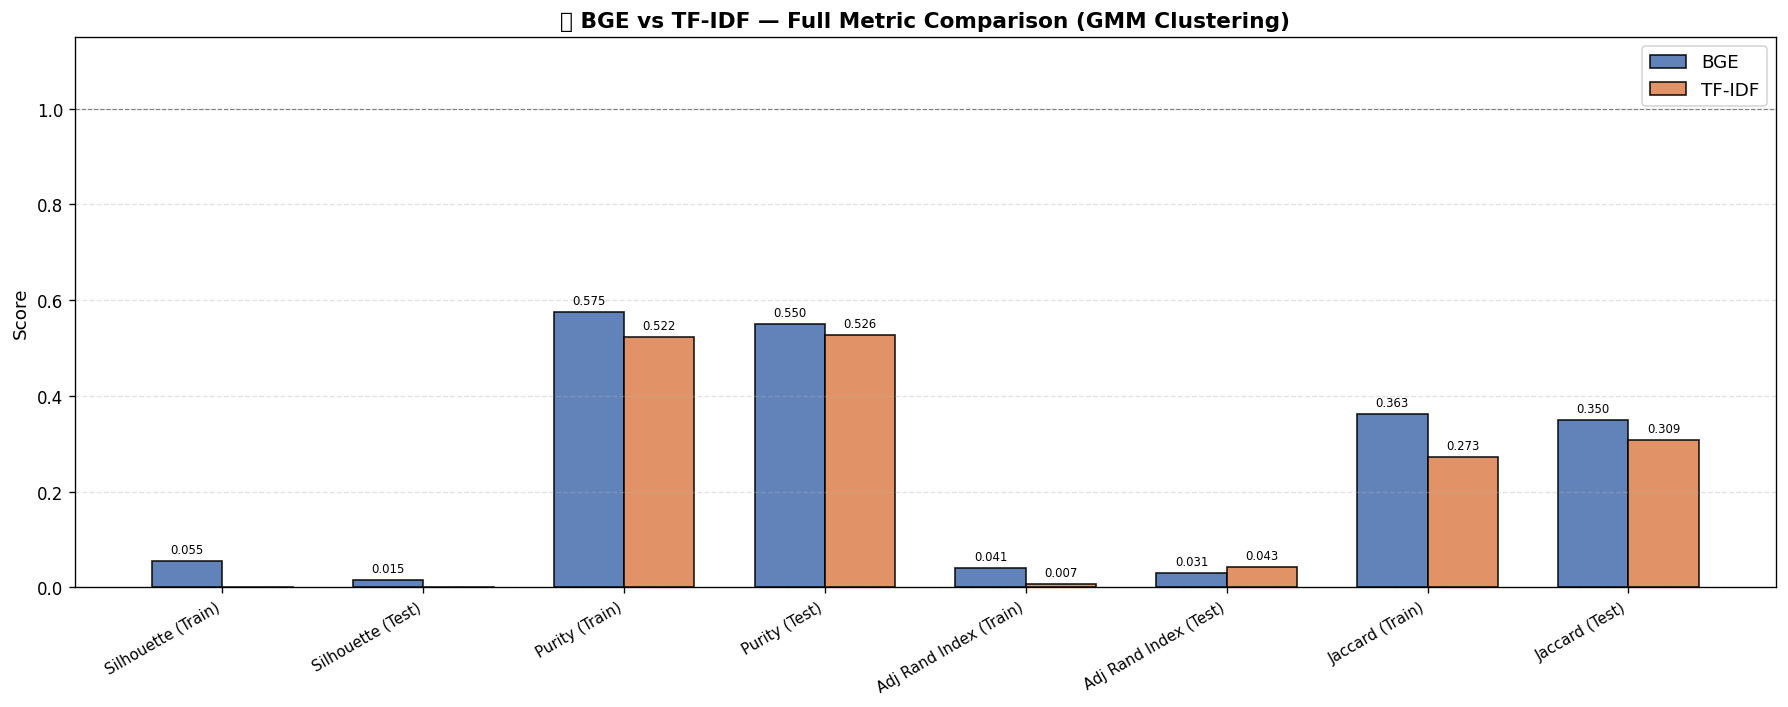

In [56]:
# ─── Grouped Bar Chart: All Metrics ──────────────────────────────────────────────
plot_metrics = ['Silhouette (Train)', 'Purity (Train)', 'Adj Rand Index (Train)',
                'Jaccard (Train)', 'Silhouette (Test)', 'Purity (Test)',
                'Adj Rand Index (Test)', 'Jaccard (Test)']

plot_df = comparison_df[comparison_df['Metric'].isin(plot_metrics)].copy()
x       = np.arange(len(plot_df))
width   = 0.35

fig, ax = plt.subplots(figsize=(15, 6))
bars_bge   = ax.bar(x - width/2, plot_df['BGE'],    width, label='BGE',    color='#4C72B0', edgecolor='black', alpha=0.88)
bars_tfidf = ax.bar(x + width/2, plot_df['TF-IDF'], width, label='TF-IDF', color='#DD8452', edgecolor='black', alpha=0.88)

ax.set_title("🏆 BGE vs TF-IDF — Full Metric Comparison (GMM Clustering)",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Metric'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim([0, 1.15])
ax.axhline(1, color='grey', linestyle='--', linewidth=0.7)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# Annotate bar values
for bar in bars_bge:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=7)
for bar in bars_tfidf:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("comparison_chart_complete_dataset.png", bbox_inches='tight')
plt.show()

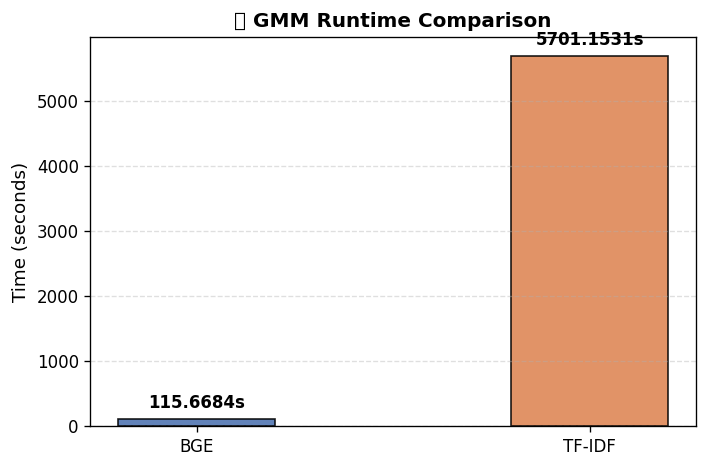


⏱️  BGE   GMM Runtime: 115.6684 s
⏱️  TF-IDF GMM Runtime: 5701.1531 s


In [57]:
# ─── Runtime Comparison ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
models  = ['BGE', 'TF-IDF']
runtimes = [bge_runtime, tfidf_runtime]
bar_cols = ['#4C72B0', '#DD8452']

bars = ax.bar(models, runtimes, color=bar_cols, edgecolor='black', alpha=0.88, width=0.4)
ax.set_title("⏱️ GMM Runtime Comparison", fontsize=12, fontweight='bold')
ax.set_ylabel("Time (seconds)", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("runtime_chart_complete_dataset.png", bbox_inches='tight')
plt.show()

print(f"\n⏱️  BGE   GMM Runtime: {bge_runtime:.4f} s")
print(f"⏱️  TF-IDF GMM Runtime: {tfidf_runtime:.4f} s")

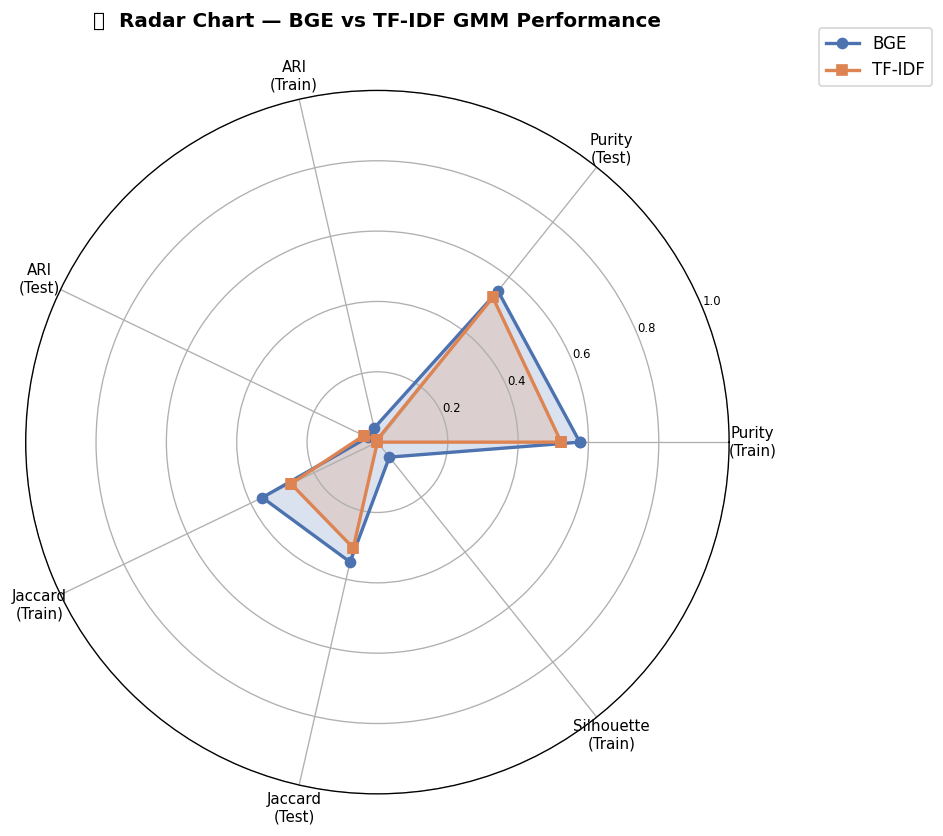

In [58]:
# ─── Radar / Spider Chart for Overall Comparison ─────────────────────────────────
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['Purity\n(Train)', 'Purity\n(Test)', 'ARI\n(Train)',
                 'ARI\n(Test)', 'Jaccard\n(Train)', 'Jaccard\n(Test)',
                 'Silhouette\n(Train)']
bge_radar    = [bge_purity_train,   bge_purity_test,
                max(0, bge_ari_train),   max(0, bge_ari_test),
                bge_jaccard_train,  bge_jaccard_test,
                max(0, bge_sil_train)]
tfidf_radar  = [tfidf_purity_train, tfidf_purity_test,
                max(0, tfidf_ari_train), max(0, tfidf_ari_test),
                tfidf_jaccard_train,tfidf_jaccard_test,
                max(0, tfidf_sil_train)]

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

bge_radar   += bge_radar[:1]
tfidf_radar += tfidf_radar[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, bge_radar,   'o-', linewidth=2, color='#4C72B0', label='BGE')
ax.fill(angles, bge_radar,   alpha=0.2, color='#4C72B0')
ax.plot(angles, tfidf_radar, 's-', linewidth=2, color='#DD8452', label='TF-IDF')
ax.fill(angles, tfidf_radar, alpha=0.2, color='#DD8452')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=9)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)
ax.set_ylim(0, 1)
ax.set_title("🕸️  Radar Chart — BGE vs TF-IDF GMM Performance",
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig("radar_chart_complete_dataset.png", bbox_inches='tight')
plt.show()

In [59]:
# ─── Determine Best Model & Print Final Summary ──────────────────────────────────

# Score: higher is better for purity, ARI, jaccard, silhouette
# Lower is better for WSS and runtime
bge_score_sum   = (bge_purity_train + bge_purity_test +
                   bge_ari_train    + bge_ari_test +
                   bge_jaccard_train + bge_jaccard_test +
                   bge_sil_train    + bge_sil_test)

tfidf_score_sum = (tfidf_purity_train + tfidf_purity_test +
                   tfidf_ari_train    + tfidf_ari_test +
                   tfidf_jaccard_train + tfidf_jaccard_test +
                   tfidf_sil_train    + tfidf_sil_test)

best_model  = "BGE" if bge_score_sum >= tfidf_score_sum else "TF-IDF"
best_purity = bge_purity_test if best_model == "BGE" else tfidf_purity_test
best_purity_train = bge_purity_train if best_model == "BGE" else tfidf_purity_train

separator = "=" * 65

print(separator)
print("         🏆  FINAL MODEL COMPARISON SUMMARY")
print(separator)
print(f"  {'Metric':<30} {'BGE':>10} {'TF-IDF':>10}")
print(f"  {'-'*52}")
print(f"  {'Aggregate Score (higher=better)':<30} {bge_score_sum:>10.4f} {tfidf_score_sum:>10.4f}")
print(f"  {'Purity (Train)':<30} {bge_purity_train:>10.4f} {tfidf_purity_train:>10.4f}")
print(f"  {'Purity (Test)':<30} {bge_purity_test:>10.4f}  {tfidf_purity_test:>10.4f}")
print(f"  {'Silhouette (Train)':<30} {bge_sil_train:>10.4f}  {tfidf_sil_train:>10.4f}")
print(f"  {'Adj Rand Index (Train)':<30} {bge_ari_train:>10.4f}  {tfidf_ari_train:>10.4f}")
print(f"  {'Jaccard (Train)':<30} {bge_jaccard_train:>10.4f}  {tfidf_jaccard_train:>10.4f}")
print(f"  {'Runtime (s)':<30} {bge_runtime:>10.4f}  {tfidf_runtime:>10.4f}")
print(separator)
print(f"\n  🥇  BETTER MODEL : {best_model}")
print(f"\n  📌  Justification:")
if best_model == "BGE":
    print("      BGE embeddings are dense semantic representations produced by a")
    print("      pre-trained transformer (BAAI/bge). They capture rich contextual")
    print("      meaning, resulting in tighter, more separable clusters compared")
    print("      to sparse TF-IDF vectors which are purely frequency-based and")
    print("      do not encode semantic similarity.")
else:
    print("      TF-IDF vectors outperformed BGE embeddings on this dataset.")
    print("      This may indicate that term-frequency patterns are more")
    print("      discriminative than dense semantic embeddings for this particular")
    print("      clinical note corpus, possibly due to domain-specific jargon.")

print(f"\n  ✅  Best Model Accuracy (Purity — Test  Set): {best_purity:.4f}  "
      f"({best_purity*100:.2f}%)")
print(f"  ✅  Best Model Accuracy (Purity — Train Set): {best_purity_train:.4f}  "
      f"({best_purity_train*100:.2f}%)")
print(separator)

         🏆  FINAL MODEL COMPARISON SUMMARY
  Metric                                BGE     TF-IDF
  ----------------------------------------------------
  Aggregate Score (higher=better)     1.9794     1.3253
  Purity (Train)                     0.5755     0.5224
  Purity (Test)                      0.5497      0.5263
  Silhouette (Train)                 0.0545     -0.0319
  Adj Rand Index (Train)             0.0411      0.0065
  Jaccard (Train)                    0.3631      0.2729
  Runtime (s)                      115.6684   5701.1531

  🥇  BETTER MODEL : BGE

  📌  Justification:
      BGE embeddings are dense semantic representations produced by a
      pre-trained transformer (BAAI/bge). They capture rich contextual
      meaning, resulting in tighter, more separable clusters compared
      to sparse TF-IDF vectors which are purely frequency-based and
      do not encode semantic similarity.

  ✅  Best Model Accuracy (Purity — Test  Set): 0.5497  (54.97%)
  ✅  Best Model Accuracy 

In [60]:
# ─── Final Styled Comparison Table (Pandas Styling) ──────────────────────────────
display(
    comparison_df.style
    .applymap(
        lambda v: 'background-color: #d4edda; color: black; font-weight: bold'
                  if isinstance(v, str) and '✅' in v else '',
        subset=['Better']
    )
    .format({'BGE': '{:.4f}', 'TF-IDF': '{:.4f}'}, na_rep='-')
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('font-size', '12px')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#f5f5f5')]},
    ])
    .set_caption("📊 Full Metric Comparison — BGE vs TF-IDF (GMM Clustering, 13 Clusters)")
    .hide(axis='index')
)

Metric,BGE,TF-IDF,Better
WSS (Train),1598.6139,5130796.2832,BGE ✅
WSS (Test),91.0320,1081985.8111,BGE ✅
Silhouette (Train),0.0545,-0.0319,BGE ✅
Silhouette (Test),0.0150,-0.3226,BGE ✅
Purity (Train),0.5755,0.5224,BGE ✅
Purity (Test),0.5497,0.5263,BGE ✅
Adj Rand Index (Train),0.0411,0.0065,BGE ✅
Adj Rand Index (Test),0.0309,0.0431,TF-IDF ✅
Jaccard (Train),0.3631,0.2729,BGE ✅
Jaccard (Test),0.3496,0.3086,BGE ✅
